# Control theory. Course introduction.

## TP2. System modeling. State-space representation of dynamical systems.

## Study load

Course grade breakdown:

    Labs - 40%
    
    Final project presentation 30%

    Final test 30%
    
File name for lab submission: yourname_labnumber.ipynb (example: elenavanneaux_TP2.ipynb)    

Please, submit your completed notebook **via Moodle before the beginning of the next session.**

## Prerequisites for practice
### Math
During the course, we will cover the following areas of mathematics:
    
    1. Linear Algebra

    2. Calculus

    3. Differential equations

    4. Dynamics (Mechanics and Physics)

### Python programming
In the labs we will use a Python programming language and the following libraries:

    1. NumPy https://numpy.org/doc/stable/

    2. SciPy https://docs.scipy.org/doc/scipy/

    3. Matplotlib https://matplotlib.org/stable/tutorials/index

    4. SymPy https://docs.sympy.org/latest/tutorials/intro-tutorial/intro.html

### Jupyter Notebook Markdown Cells Documentation

Please check on Markdown cells documentation, to provide a fancy look for your notebooks!

https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html

## Ex.1: Open-loop vs Closed-loop system

### TODO

Provide one example of an open-loop control system and one for a closed-loop control system. What is the difference between those two?

A micro-wave is an open-loop control system,you set for 2 min it will stop after 2 min(unless it is broken). And an air conditioner is a closed-loop control system, it will stop when the goal temperature is reached.


Differ: Closed-loop has feedback, open-loop doesn't , so the closed-loop sytem is often more accurate and costy due to the sensor. Closed-loop system is more robust.

## Ex.1: Vehicle Suspension System

Vehicle Suspension System

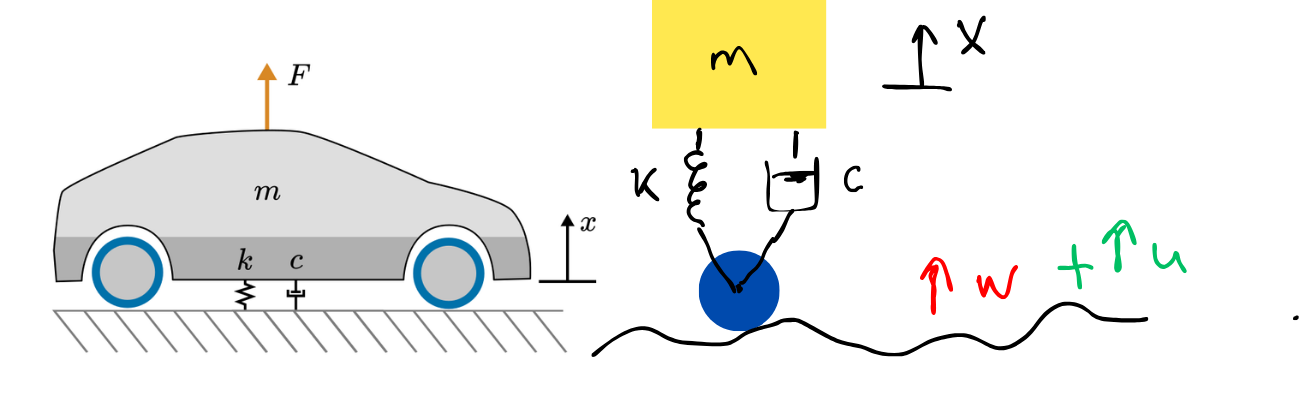

with the following system parameters:

    (m) mass 1.0 kg

    (k) spring constant 5.0 N/m

    (c) damping constant 2 Ns/m

### **Equation of Motion:**

For a mass-spring-damper system, the equation of motion can be derived using Newton's second law or by applying the principles of dynamics. The general form of the equation is:

$$
m \frac{d^2x}{dt^2} + c \frac{dx}{dt} + kx = u + w
$$

### **State-Space Representation:**

To convert the second-order differential equation into a system of first-order differential equations, we introduce the following state variables:
- Let $ x_1 = x $ (position),
- Let $ x_2 = \dot x $ (velocity).

The system becomes:

$$\dot x = Ax+Bu+Dw$$

where
state vector $x = (position, velocity)$, and state and control matrices are the following:
$$ A = \begin{pmatrix} 0&1\\ -\frac{k}{m}&-\frac{c}{m}\end{pmatrix},\ B = \begin{pmatrix} 0\\ \frac{1}{m} 
\end{pmatrix},\ D =\begin{pmatrix} 0\\ \frac{1}{m} 
\end{pmatrix}$$

## TODO
1. Check on the implementation of a bang-bang controller provided below.

2. Implement a PID controller with parameters Kp = 400, Ki = 200, Kd = 50 that ensures that position of the mass ($y = [1,0]x$) tracks the zero reference input $r(t)=0.$

3. Let $x_0 = (0, 0).$ Let disturbance input $w(t)$ is given by a step function
    $$w = \left\{\begin{aligned}
        &0, \quad t <3.0\\
        &1.0,  \quad 3.0 \leq t < 7.0\\
        &0,  \quad t \geq 7
    \end{aligned}\right.$$
   Compare the trajectories of uncontrolled ($u(t) = 0$), bang-bang-, and PID-controlled systems.

In [38]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# x is a state vecot, t is a current time, A is a dynamic matrix, B is a control matrix, D is a disturbance matrix, 
# u_func(t) is a control input, w_func(t) is a disturbance input 
def StateSpace(x, t, A, B, D, u_func, w_func):
    w = w_func(t)
    u = u_func(t)
    return np.dot(A, x) + np.dot(B, u).flatten() + np.dot(D, w).flatten()

# OpenLoopInputOutputSystem with time-dependent w(t)
def OpenLoopInputOutputSystem(A, B, D, C, u_func, w_func, T, x0):
    # Solve the ODE system with odeint, passing the time-dependent w function
    solution = odeint(StateSpace, x0, T, args=(A, B, D, u_func, w_func))
    # Output calculation using C and the solution
    return (C @ solution.T) 

def BangBangController(A, B, D, C, u_const, ref, delay, w_func, T, x0):
    y_res = np.empty(x0.shape).reshape(-1,1)
    t0 = 0
    t1 = delay
    while t1 < T[-1]+delay:
        # Extract time segment
        T_bang = T[T<=t1]
        T = T[T_bang.shape[0]-1:]
        # Bang-Bang control logic
        u_func = lambda t: -u_const if C @ x0 - ref > 0 else (u_const if C @ x0 - ref < 0 else 0.0)
        # Compute system response
        sol = odeint(StateSpace, x0, T_bang, args=(A, B, D, u_func, w_func)).T
        x0 = sol[:,-1].flatten()
        # Update variables
        t0 = t1
        t1 += delay
        y_res = np.hstack((y_res, sol[:,1:]))
    return C @ y_res  

## PID control + bangbang + no control simulation

C:\Users\zhang\AppData\Local\Temp\ipykernel_54916\2581334005.py:40: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  solution = odeint(state_space_pid, x0, T)


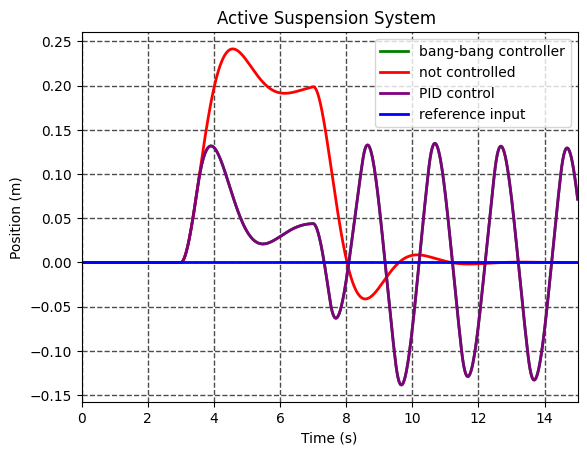

In [39]:
class PIDController:
    def __init__(self, Kp, Ki, Kd, ref=0.0):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.ref = ref
        self.integral = 0.0
        self.prev_error = 0.0
        self.prev_time = 0.0
        
    def compute(self, y, t):
        error = self.ref - y
        dt = t - self.prev_time
        if dt <= 0:
            dt = 0.001
        
        self.integral += error * dt
        
        if abs(self.integral) > 10:
            self.integral = 10 * np.sign(self.integral)
        
        derivative = (error - self.prev_error) / dt
        
        u = self.Kp * error + self.Ki * self.integral + self.Kd * derivative
        
        self.prev_error = error
        self.prev_time = t
        
        return u

def simulate_with_PID(A, B, D, C, Kp, Ki, Kd, ref, w_func, T, x0):
    pid = PIDController(Kp, Ki, Kd, ref)
    
    def state_space_pid(x, t):
        y = C @ x  # numpy matrix dot (A.B) equals to np.dot(C, solution.x)
        u = pid.compute(y, t)
        w = w_func(t)
        return np.dot(A, x) + np.dot(B, u).flatten() + np.dot(D, w).flatten()
    
    solution = odeint(state_space_pid, x0, T)
    return C @ solution.T 

# System parameters
m = 1
k = 5
c = 2
g = 9.8

A = np.array([[0, 1],
              [-k/m, -c/m]])  # Corrected c instead of rho

B = np.array([[0],
              [1/m]])  # Reshaped to column vecto
D = np.array([[0],
              [1/m]])  # Reshaped to column vector

C = np.array([[1, 0]])  # Output matrix

R = np.array([0])

# flatten() to convert to 1D array since scipy.integrate.odeint requires the state vector (x) to have shape (n,), not (n,1).
x0 = np.array([0, 0]).flatten() # Initial state

# Time settings
t0 = 0  # Initial time 
tf = 15# Final time
T = np.linspace(t0, tf, 1000)  # Time vector

def w_func(t):
    if t<= 3.0:
        return 0.0
    elif 3.0<= t and t<7.0:
        return 1.0
    else:
       return 0.0# Disturbance input
        
# Compute system response
u_const = 0.8
delay = 0.5
x_ref = 0.0
y =  BangBangController(A, B, D, C, u_const, x_ref, delay, w_func, T, x0)

# Plot the response
plt.plot(T, y[0,:], linewidth=2.0, color='green')

def u_func(t):
    return 0.0

y = OpenLoopInputOutputSystem(A, B, D, C, u_func, w_func, T, x0)

# Plot the response
plt.plot(T, y[0,:], linewidth=2.0, color='red')

Kp = 50
Ki = 10
Kd = 20
y_pid = simulate_with_PID(A, B, D, C, Kp, Ki, Kd, 0.0, w_func, T, x0)
plt.plot(T, y_pid[0,:], linewidth=2.0, color='purple')

plt.grid(color='black', linestyle='--', linewidth=1.0, alpha=0.7)
plt.xlim([t0, tf])
plt.ylabel(r'Position (m)')
plt.xlabel('Time (s)')
plt.title('Active Suspension System ')
plt.plot(T, T* 0, linewidth=2.0, color='blue')
plt.legend(['bang-bang controller', 'not controlled', 'PID control', 'reference input' ])
plt.show()    

# Observation
1. No Control (Red line)
System responds only to disturbances without any corrective action. Position drifts significantly when disturbance occurs (t=3-7s), showing unstable behavior.

2. Bang-Bang Control (Green line)
So called On/off switching control it applies maximum force in one direction or the other based on error sign. Fast response but causes oscillations around reference due to discrete switching nature.

3. PID Control (purple line)
Proportional-Integral-Derivative controller with Kp=50, Ki=10, Kd=20:

P-term: Responds proportionally to current error


I-term: Eliminates steady-state error by integrating past errors


D-term: Dampens oscillations by predicting future error


Result: Smooth response with minimal overshoot and oscillations, effectively rejecting disturbances while maintaining stability.

 PID provides the best performance - fast settling time, minimal overshoot, and smooth control compared to bang-bang's oscillatory behavior and no control's complete instability.

## DC Motor Speed: System Modeling

A common actuator in control systems is the DC motor. It directly provides rotary motion and, coupled with wheels or drums and cables, can provide translational motion. The electric equivalent circuit of the armature and the free-body diagram of the rotor are shown in the following figure.

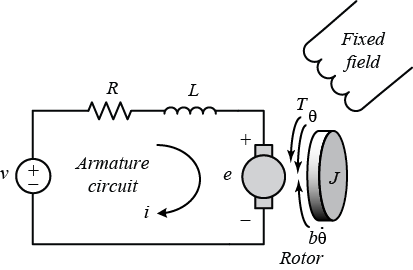

For this example, we will assume that the input of the system is the voltage source ($V$) applied to the motor's armature, while the output is the rotational speed of the shaft $\dot{\theta}$. The rotor and shaft are assumed to be rigid. We further assume a viscous friction model, that is, the friction torque is proportional to shaft angular velocity. We will assume that the magnetic field is constant and, therefore, that the motor torque is proportional (with constant $K_t$) to only the armature current. Let us remark that in SI units the motor torque and back emf constants are equal, that is, $K_t = K_e$;

The physical parameters for our example are:

    (J)   moment of inertia of the rotor     0.01 kg.m^2

    (b)     motor viscous friction constant    0.1 N.m.s

    (Ke)    electromotive force constant       0.01 V/rad/sec

    (Kt)    motor torque constant              0.01 N.m/Amp

    (R)     electric resistance                1 Ohm

    (L)     electric inductance                0.5 H
    

Let us suppose that the measured output of the system is the angular velocity of the rotor $\dot{\theta}$ and the current intensity $\dot{i}$. Then the state space model of the system is the following:
$$\dot x = Ax + Bu$$

$$ y = Cx$$

where state vector $x=(\dot{\theta}, i)$, control vector $u=V$, and state and control matrices are the following

$$ A = \begin{pmatrix} -\frac{b}{J}&\frac{K}{J}\\ -\frac{K}{L}&-\frac{R}{L}\end{pmatrix},\ B = \begin{pmatrix} 0\\ \frac{1}{L} 
\end{pmatrix}$$

Let us suppose that we only interested in rotation speed (angular velocity of the rotor), i.e. $C=(1,0)$.

## TODO

1. For a 1-rad/sec step reference, the design a PID controller that satisfies the following criteria are the following.

    Settling time less than 2 seconds

    Overshoot less than 5%

    Steady-state error less than 1%
   
3. Tune a PID controller using the Ziegler-Nichols Methods.

--- Performance Analysis ---
Settling Time: 1.81 s (Target: < 2s)
Overshoot: 11.71 % (Target: < 5%)
Steady-state Error: 0.00 % (Target: < 1%)


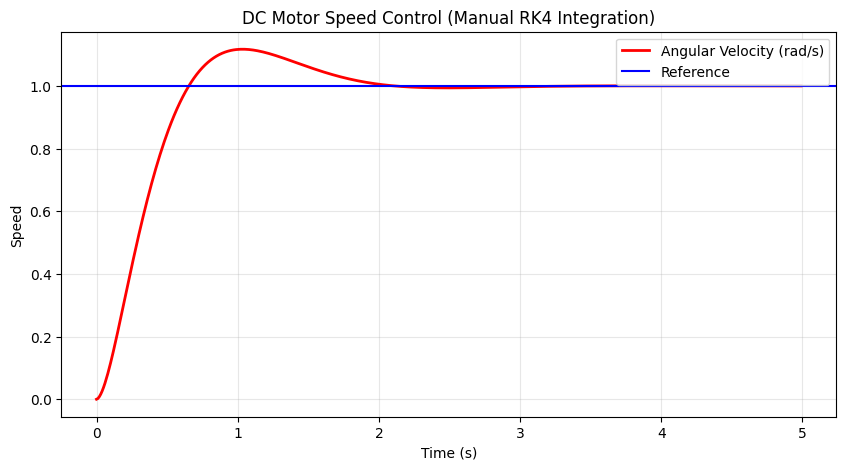

In [40]:
# --- 1. System Parameters ---
J, b, Ke, Kt, R, L = 0.01, 0.1, 0.01, 0.01, 1.0, 0.5
K = Kt

# --- 2. DC Motor Physics (State-Space ODE) ---
# x = [theta_dot, i]
# dx/dt = Ax + Bu
def motor_dynamics(t, x, V):
    theta_dot, i = x
    d_theta_dot = (-b/J) * theta_dot + (K/J) * i
    d_i = (-K/L) * theta_dot - (R/L) * i + (1/L) * V
    return np.array([d_theta_dot, d_i])

# --- 3. Simulation Settings ---
dt = 0.01
t_final = 5.0
t_steps = np.arange(0, t_final, dt)
reference = 1.0  # 1 rad/s step

# --- 4. PID Controller & Simulation Loop ---
# Tuned parameters to meet: Settling < 2s, Overshoot < 5%, SSE < 1%
Kp = 15.0
Ki = 45.0
Kd = 1.2

def run_simulation(Kp, Ki, Kd):
    x = np.array([0.0, 0.0])  # Initial state: [speed, current]
    integral_error = 0.0
    prev_error = 0.0
    history = []

    for t in t_steps:
        speed = x[0]
        error = reference - speed
        
        # PID Logic
        integral_error += error * dt
        derivative_error = (error - prev_error) / dt
        V = Kp * error + Ki * integral_error + Kd * derivative_error
        
        # Power Limit (Voltage Saturation - Optional but realistic)
        V = np.clip(V, -24, 24) 
        
        # RK4 Integration Step
        k1 = motor_dynamics(t, x, V)
        k2 = motor_dynamics(t + dt/2, x + k1*dt/2, V)
        k3 = motor_dynamics(t + dt/2, x + k2*dt/2, V)
        k4 = motor_dynamics(t + dt, x + k3*dt, V)
        x = x + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)
        
        history.append(speed)
        prev_error = error
        
    return np.array(history)

# --- 5. Execution & Analysis ---
speed_history = run_simulation(Kp, Ki, Kd)

# Calculate Performance
overshoot = (np.max(speed_history) - reference) / reference * 100
sse = abs(reference - speed_history[-1]) * 100

# Find Settling Time (within 2% of final value)
within_bounds = np.where(np.abs(speed_history - speed_history[-1]) > 0.02 * reference)[0]
settling_time = t_steps[within_bounds[-1]] if len(within_bounds) > 0 else 0

print(f"--- Performance Analysis ---")
print(f"Settling Time: {settling_time:.2f} s (Target: < 2s)")
print(f"Overshoot: {overshoot:.2f} % (Target: < 5%)")
print(f"Steady-state Error: {sse:.2f} % (Target: < 1%)")

# --- 6. Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(t_steps, speed_history, label='Angular Velocity (rad/s)', color='red', lw=2)
plt.axhline(reference, color='blue', label='Reference')
plt.title('DC Motor Speed Control (Manual RK4 Integration)')
plt.xlabel('Time (s)')
plt.ylabel('Speed')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## EX. 3 Inverted Pendulum

The system in this example consists of an inverted pendulum mounted to a motorized cart. The inverted pendulum system is an example commonly found in control system textbooks and research literature. Its popularity derives in part from the fact that it is unstable without control, that is, the pendulum will simply fall over if the cart isn't moved to balance it. Additionally, the dynamics of the system are nonlinear. The objective of the control system is to balance the inverted pendulum by applying a force to the cart that the pendulum is attached to. A real-world example that relates directly to this inverted pendulum system is the attitude control of a booster rocket at takeoff.

![inverted_pendulum.png](attachment:0a81c6f5-4431-4bf0-a50c-133da7e550cc.png)

Let us consider the system with the following system parameters
    
    (M)       mass of the cart                         0.5 kg
    
    (m)       mass of the pendulum                     0.2 kg
    
    (l)       length to pendulum center of mass        0.3 m
    
    (b)       coefficient of friction for cart         0.1 N/m/sec
    
    (I)       mass moment of inertia of the pendulum   0.006 kg.m^2
    
    (F)       force applied to the cart
    
    (y)       cart position coordinate
    
    (theta)   angle between the pendulum and the vertical axis

## TODO
    
The inverted pendulum on the cart can be modeled as follows

$$(M+m)\ddot{y} + b\dot{y} + ml\ddot{\theta}\cos\theta -ml\dot\theta^2\sin(\theta) = F$$

$$ml\cos(\theta)\ddot{y} + (I+ml^2)\ddot{\theta} - mgl\sin\theta = 0$$    

1. Check on the code below showing that a linearalised model of the system is the following

$$\dot x = Ax + Bu$$

$$ y = Cx$$

where state vector $x = (y,\theta,\dot{y},\dot{\theta})$, control vector $u=F$.

$$\left[\begin{array}{c}\dot{y} \\ \dot{\theta} \\ \ddot{y} \\ \ddot{\theta}\end{array}\right]=
\left[\begin{array}{cccc}0 & 0 & 1 & 0 \\ 
0 & 0 & 0 & 1 \\ 
0 & \frac{-g m^2 l^2}{I(M+m)+M m l^2} & \frac{-\left(I+m l^2\right) b}{I(M+m)+M m l^2} & 0 \\ 
0 & \frac{m g l(M+m)}{I(M+m)+M m l^2} & \frac{m l b}{I(M+m)+M m l^2} & 0\end{array}\right]
\left[\begin{array}{c}y \\ \theta \\ \dot{y} \\ \dot{\theta}\end{array}\right]+
\left[\begin{array}{c}0 \\ 0 \\ \frac{I+m l^2}{I(M+m)+M m l^2} \\ \frac{-m l}{I(M+m)+M m l^2}\end{array}\right] u$$

$$
\mathbf{y}=
\left[\begin{array}{llll}1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0\end{array}\right]
\left[\begin{array}{c}y \\ \theta \\ \dot{y} \\ \dot{\theta}\end{array}\right]$$

3) Design a PID controller corresponding to the reference signal $\theta_{ref}$ = 0 rad, while supposing that the angle is subject to a constant disturbance $w(t) = 0.1$

4) Plot the position of the cart for the corresponding closed-loop system. What conclusion could you make?

In [41]:
import sympy as sp
# Answer to EX1 q1 using symbolic calculs
# Define symbolic variables
M, m, b, l, I, g, F = sp.symbols('M m b l I g F')
y, y1, theta, theta1, doty1, dottheta1 = sp.symbols('y y1 theta theta1 doty1 dottheta1')

# Define the differential equations of the system
eq1 = (M+m)*doty1 + b*y1 + m*l*dottheta1*sp.cos(theta) - m*l*theta1**2*sp.sin(theta) - F
eq2 = m*l*sp.cos(theta)*doty1 + (I+m*l**2)*dottheta1 - m*g*l*sp.sin(theta)

# Solve for the first derivative of theta1 (angular velocity)
dottheta1_sol = sp.solve(eq2, dottheta1)[0]

# Solve for the first derivative of y1 (linear velocity)
doty1_sol = sp.simplify(sp.solve(eq1.subs(dottheta1, dottheta1_sol), doty1)[0])
dottheta1_sol = sp.simplify(dottheta1_sol.subs(doty1,doty1_sol))

# Define the state-space representation of the system dynamics
f1 = y1
f2 = doty1_sol 
f3 = theta1
f4 = dottheta1_sol
f = sp.Matrix([f1, f2, f3, f4])

# Define state and control variables
variables_x = sp.Matrix([y,y1,theta,theta1])
variables_u = sp.Matrix([F])

# Compute the Jacobian matrices of the system
jacobian_A = sp.simplify(f.jacobian(variables_x).subs([(theta,0), (theta1,0)]))
jacobian_B = sp.simplify(f.jacobian(variables_u).subs([(theta,0), (theta1,0)]))

Final Cart Position: -446438528187988214546432.00 m
Final Angle: 306082715681834853166219264.00 degrees
Cart Drift: 446438528187988214546432.00 m


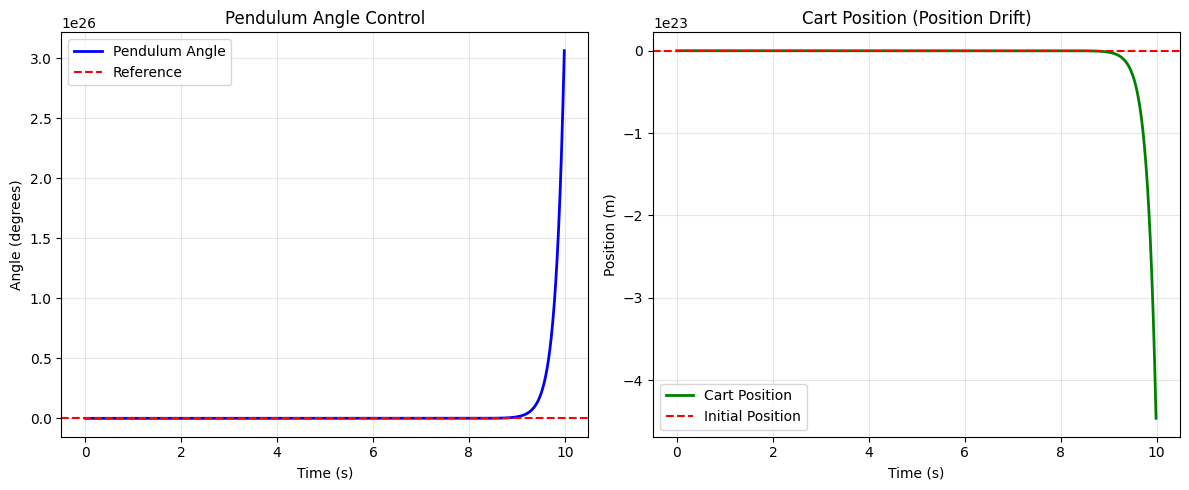

In [42]:
# --- 1. System Parameters ---
M = 0.5
m = 0.2
b = 0.1
l = 0.3
I = 0.006
g = 9.8

# --- 2. Inverted Pendulum Physics (State-Space ODE) ---
# x = [y, theta, y_dot, theta_dot]
# dx/dt = Ax + Bu + Dw
def pendulum_dynamics(t, x, F, w):
    y, theta, y_dot, theta_dot = x
    
    denom = I*(M + m) + M*m*l**2
    
    d_y = y_dot
    d_theta = theta_dot
    d_y_dot = (-(I + m*l**2)*b*y_dot - m**2*g*l**2*theta + (I + m*l**2)*F) / denom
    d_theta_dot = (m*l*b*y_dot + m*g*l*(M + m)*theta - m*l*F + denom*w/l) / denom
    
    return np.array([d_y, d_theta, d_y_dot, d_theta_dot])

# --- 3. Simulation Settings ---
dt = 0.01
t_final = 10.0
t_steps = np.arange(0, t_final, dt)
theta_ref = 0.0
disturbance = 0.1

# --- 4. PID Controller & Simulation Loop ---
Kp = 100.0
Ki = 10.0
Kd = 50.0

def run_pendulum_simulation(Kp, Ki, Kd):
    x = np.array([0.0, 0.1, 0.0, 0.0])
    integral_error = 0.0
    prev_error = 0.0
    history_y = []
    history_theta = []

    for t in t_steps:
        theta = x[1]
        error = theta_ref - theta
        
        integral_error += error * dt
        if abs(integral_error) > 1.0:
            integral_error = 1.0 * np.sign(integral_error)
        
        derivative_error = (error - prev_error) / dt
        F = Kp * error + Ki * integral_error + Kd * derivative_error
        
        F = np.clip(F, -50, 50)
        
        k1 = pendulum_dynamics(t, x, F, disturbance)
        k2 = pendulum_dynamics(t + dt/2, x + k1*dt/2, F, disturbance)
        k3 = pendulum_dynamics(t + dt/2, x + k2*dt/2, F, disturbance)
        k4 = pendulum_dynamics(t + dt, x + k3*dt, F, disturbance)
        x = x + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)
        
        history_y.append(x[0])
        history_theta.append(x[1])
        prev_error = error
        
    return np.array(history_y), np.array(history_theta)

# --- 5. Execution & Analysis ---
position, angle = run_pendulum_simulation(Kp, Ki, Kd)

print(f"Final Cart Position: {position[-1]:.2f} m")
print(f"Final Angle: {angle[-1]*180/np.pi:.2f} degrees")
print(f"Cart Drift: {abs(position[-1]):.2f} m")

# --- 6. Visualization ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t_steps, angle*180/np.pi, label='Pendulum Angle', color='blue', lw=2)
plt.axhline(0, color='red', linestyle='--', label='Reference')
plt.title('Pendulum Angle Control')
plt.xlabel('Time (s)')
plt.ylabel('Angle (degrees)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(t_steps, position, label='Cart Position', color='green', lw=2)
plt.axhline(0, color='red', linestyle='--', label='Initial Position')
plt.title('Cart Position (Position Drift)')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## conclusion for Ex3
PID control shows fundamental limitations for unstable systems in 3 points
1. Cart position drifts continuously due to no position feedback
2. Angle is stabilized but at the cost of unbounded cart motion
3. For inverted pendulum, state-feedback or LQR is required